## PREPROCESSING

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
df = pd.read_parquet("US_accidents_dataset.parquet")
df.drop(columns=["Turning_Loop", "End_Lat", "End_Lng", "Airport_Code"], inplace=True)
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['End_Time'] = pd.to_datetime(df['End_Time'], format='mixed')
df['duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
df['hour'] = df['Start_Time'].dt.hour
df['month'] = df['Start_Time'].dt.month

# Rimuovi durate assurde (es. negativi o > 7 giorni)
df = df[(df['duration_min'] >= 0) & (df['duration_min'] < 10080)]

def is_us_holiday(dt):
    m, d = dt.month, dt.day
    
    # Natale e capodanno
    if (m == 12 and d >= 24) or (m == 1 and d <= 2):
        return 1
    # Thanksgiving (novembre, ultima settimana)
    if m == 11 and d >= 22:
        return 1
    # 4 luglio - Independence Day
    if m == 7 and d == 4:
        return 1
    # Memorial Day (fine maggio)
    if m == 5 and d >= 25:
        return 1
    # Labor Day (inizio settembre)
    if m == 9 and d <= 7:
        return 1
    # Halloween
    if m == 10 and d == 31:
        return 1
    # Super Bowl Sunday (prima domenica di febbraio ~7-10 feb)
    if m == 2 and 7 <= d <= 10:
        return 1
    
    return 0

df['is_holiday_period'] = df['Start_Time'].apply(is_us_holiday)
df.drop(columns=['Start_Time', 'End_Time', 'Weather_Timestamp'], inplace=True)
df.drop(columns=['Wind_Chill(F)'], inplace=True)
df.drop(columns=['Country'], inplace=True)
def group_weather(w):
    if pd.isna(w):
        return 'Unknown'
    w = str(w).lower()
    
    if any(x in w for x in ['thunder', 't-storm', 'thunderstorm']):
        return 'Storm'
    if 'tornado' in w or 'funnel' in w:
        return 'Storm'
    if any(x in w for x in ['snow', 'blizzard', 'wintry', 'sleet', 'ice pellet', 'snow grain', 'freezing']):
        return 'Snow_Ice'
    if any(x in w for x in ['hail', 'small hail']):
        return 'Snow_Ice'
    if any(x in w for x in ['heavy rain', 'rain shower', 'rain']):
        return 'Rain'
    if any(x in w for x in ['drizzle', 'shower']):
        return 'Rain'
    if any(x in w for x in ['fog', 'mist', 'haze']):
        return 'Fog_Low_Visibility'
    if any(x in w for x in ['smoke', 'dust', 'sand', 'ash', 'squall']):
        return 'Dust_Smoke'
    if any(x in w for x in ['cloud', 'overcast', 'scattered', 'mostly', 'partly']):
        return 'Cloudy'
    if any(x in w for x in ['clear', 'fair', 'sunny']):
        return 'Clear'
    return 'Other'

def is_windy_condition(w):
    if pd.isna(w):
        return np.nan
    return 1 if 'windy' in str(w).lower() else 0

def weather_intensity(w):
    if pd.isna(w):
        return np.nan
    w = str(w).lower()
    if any(x in w for x in ['heavy', 'severe', 'tornado', 'funnel', 'blizzard', 'duststorm']):
        return 3
    if any(x in w for x in ['moderate', 'thunder', 't-storm', 'squall', 'wintry mix']):
        return 2
    if any(x in w for x in ['light', 'drizzle', 'mist', 'shallow', 'partial', 'patches']):
        return 1
    return 0

df['Weather_Group'] = df['Weather_Condition'].apply(group_weather)
df['Weather_Windy'] = df['Weather_Condition'].apply(is_windy_condition)
df['Weather_Intensity'] = df['Weather_Condition'].apply(weather_intensity)

df.drop(columns=['Weather_Condition'], inplace=True)
import re

def classify_street(name):
    if pd.isna(name):
        return 'Unknown'
    name_upper = str(name).upper().strip()
    
    # Rimuovi direzione finale per non confonderla col tipo
    name_clean = re.sub(r'\s+(N|S|E|W|NE|NW|SE|SW)$', '', name_upper).strip()
    
    # Interstate highways (I-95, I-10 ecc.)
    if re.match(r'^I-\d+', name_clean):
        return 'Interstate'
    
    # US Routes (US-101, US-1 ecc.)
    if re.match(r'^US-\d+', name_clean):
        return 'US_Route'
    
    # State Routes (CA-99, CA-60 ecc.)
    if re.match(r'^[A-Z]{2}-\d+', name_clean):
        return 'State_Route'
    
    # Freeway con nome (Golden State Fwy, San Diego Fwy ecc.)
    if any(x in name_clean for x in ['FWY', 'FREEWAY', 'EXPRESSWAY', 'EXPY', 'TPKE', 'TURNPIKE', 'PIKE']):
        return 'Freeway_Expressway'
    
    if any(x in name_clean for x in ['HWY', 'HIGHWAY']):
        return 'Highway'
    
    if any(x in name_clean for x in ['PKWY', 'PARKWAY']):
        return 'Parkway'
    
    if any(x in name_clean for x in ['BLVD', 'BOULEVARD']):
        return 'Boulevard'
    
    if any(x in name_clean for x in [' AVE', 'AVENUE']):
        return 'Avenue'
    
    if any(x in name_clean for x in [' RD', ' ROAD']):
        return 'Road'
    
    if any(x in name_clean for x in [' ST', ' STREET']):
        return 'Street'
    
    if any(x in name_clean for x in [' DR', ' DRIVE']):
        return 'Drive'
    
    if any(x in name_clean for x in [' LN', ' LANE']):
        return 'Lane'
    
    if any(x in name_clean for x in [' TRL', ' TRAIL']):
        return 'Trail'
    
    if any(x in name_clean for x in [' CT', ' COURT', ' CIR', ' CIRCLE', ' PL', ' PLACE', ' WAY']):
        return 'Local'
    
    return 'Other'


df['Street_Type'] = df['Street'].apply(classify_street)
df.drop(columns=['Street'], inplace=True)
df.drop(columns=['ID'], inplace=True)
df['desc_length'] = df['Description'].str.len()

# Quante corsie bloccate (più corsie = più grave)
df['lanes_blocked'] = df['Description'].str.extract(r'(\d+)\s+lane', expand=False).fillna(0).astype(int)

# Tipo di blocco
df['mentions_closed'] = df['Description'].str.contains(r'closed|closure', case=False, na=False).astype(int)
df['mentions_blocked'] = df['Description'].str.contains(r'blocked', case=False, na=False).astype(int)
df['mentions_stationary'] = df['Description'].str.contains(r'stationary traffic', case=False, na=False).astype(int)
df['mentions_slow'] = df['Description'].str.contains(r'slow traffic', case=False, na=False).astype(int)
df['mentions_delay'] = df['Description'].str.contains(r'delay|expect delay', case=False, na=False).astype(int)

# Shoulder bloccata (spalla della strada)
df['mentions_shoulder'] = df['Description'].str.contains(r'shoulder', case=False, na=False).astype(int)

# Incidente non confermato vs confermato
df['unconfirmed'] = df['Description'].str.contains(r'unconfirmed', case=False, na=False).astype(int)

# Veicoli coinvolti
df['multiple_vehicles'] = df['Description'].str.contains(r'\d+\s*veh|multiple veh', case=False, na=False).astype(int)

# Tipo di strada dalla descrizione
df['desc_highway'] = df['Description'].str.contains(r'I-\d+|interstate|freeway|fwy|pkwy|expy', case=False, na=False).astype(int)

# Caution vs crash confermato
df['drive_caution'] = df['Description'].str.contains(r'drive with caution|use caution', case=False, na=False).astype(int)
df['crash_confirmed'] = df['Description'].str.contains(r'crash|accident', case=False, na=False).astype(int)

df.drop(columns=['Description'], inplace=True)
bool_cols = ['Amenity','Bump','Crossing','Give_Way','Junction',
             'No_Exit','Railway','Roundabout','Station','Stop',
             'Traffic_Calming','Traffic_Signal', ]
df[bool_cols] = df[bool_cols].astype(int)
for col in ['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']:
    df[col] = (df[col] == 'Day').astype(int)

def time_of_day(h):
    if 6 <= h < 9:    return 0  # morning_rush
    if 9 <= h < 16:   return 1  # daytime
    if 16 <= h < 19:  return 2  # evening_rush
    if 19 <= h < 23:  return 3  # evening
    return 4                    # night

df['time_of_day'] = df['hour'].apply(time_of_day)
df.drop(columns=['hour'], inplace=True)

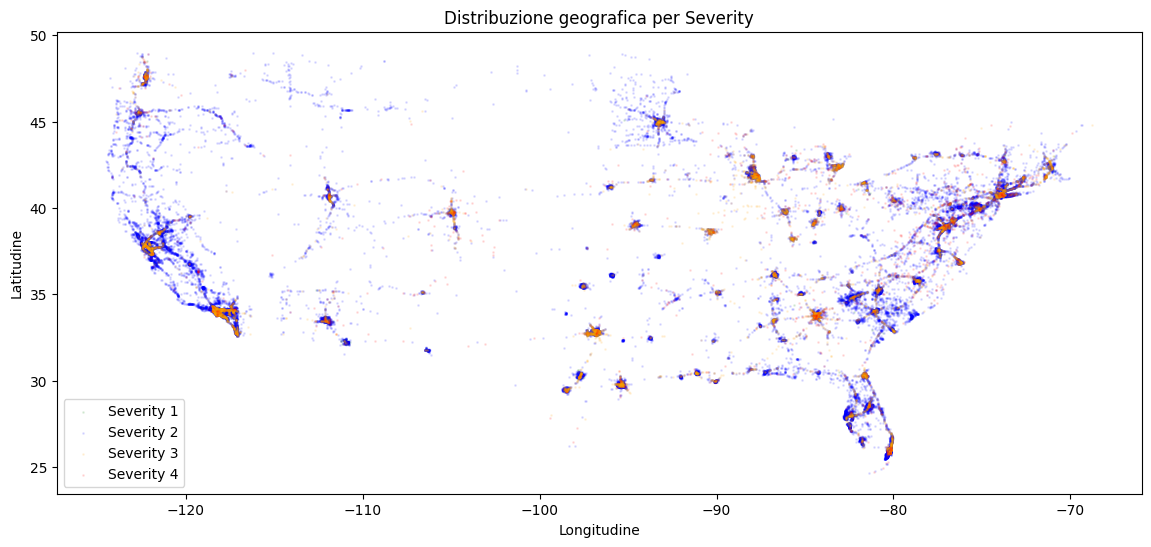

K=5 → inertia: 2082218
K=10 → inertia: 717234
K=15 → inertia: 385936
K=20 → inertia: 240392
K=25 → inertia: 184915


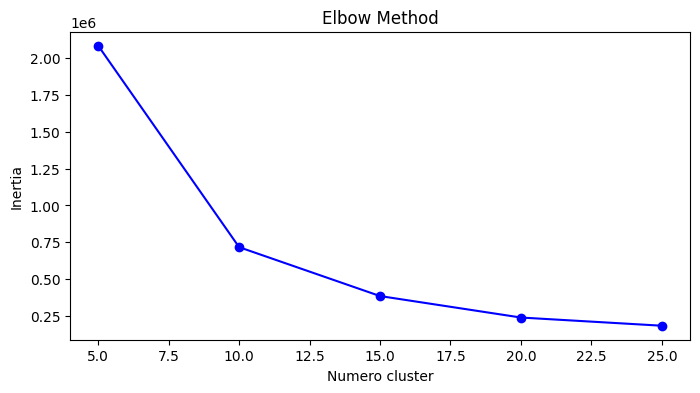

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Visualizza la distribuzione geografica colorata per severity
plt.figure(figsize=(14, 6))
colors = {1: 'green', 2: 'blue', 3: 'orange', 4: 'red'}
sample = df.sample(50000, random_state=42)

for sev in [1, 2, 3, 4]:
    mask = sample['Severity'] == sev
    plt.scatter(sample[mask]['Start_Lng'], 
                sample[mask]['Start_Lat'],
                c=colors[sev], label=f'Severity {sev}',
                alpha=0.1, s=1)

plt.xlabel('Longitudine')
plt.ylabel('Latitudine')
plt.title('Distribuzione geografica per Severity')
plt.legend()
plt.show()

# Vedi quanti cluster hanno senso con elbow method
inertias = []
K_range = range(5, 30, 5)

sample_coords = df[['Start_Lat', 'Start_Lng']].sample(100000, random_state=42)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(sample_coords)
    inertias.append(km.inertia_)
    print(f"K={k} → inertia: {km.inertia_:.0f}")

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Numero cluster')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Severity         1      2      3      4
Geo_Cluster                            
0            0.009  0.799  0.177  0.015
1            0.006  0.773  0.173  0.047
2            0.012  0.860  0.120  0.009
3            0.008  0.856  0.121  0.015
4            0.008  0.810  0.172  0.010
5            0.010  0.672  0.276  0.042
6            0.011  0.751  0.191  0.048
7            0.007  0.830  0.129  0.034
8            0.012  0.802  0.154  0.031
9            0.002  0.795  0.181  0.021


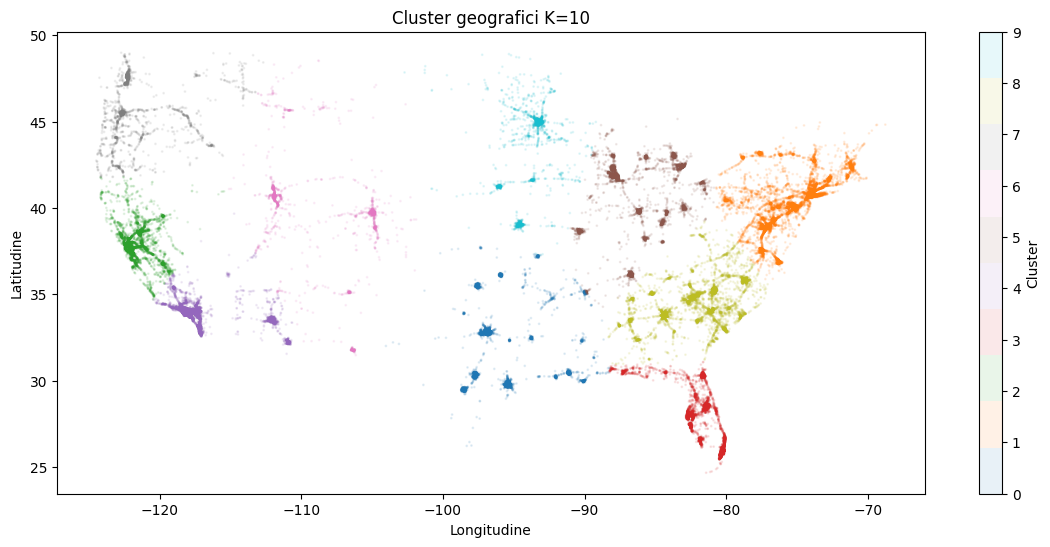

In [3]:
from sklearn.cluster import KMeans

# Fit con K=10 sul train set
km = KMeans(n_clusters=10, random_state=42, n_init=10)
km.fit(df[['Start_Lat', 'Start_Lng']].sample(200000, random_state=42))

# Assegna cluster a tutto il dataset
df['Geo_Cluster'] = km.predict(df[['Start_Lat', 'Start_Lng']])

# Verifica distribuzione severity per cluster
print(df.groupby('Geo_Cluster')['Severity'].value_counts(
    normalize=True).unstack().round(3))

# Visualizza i cluster
plt.figure(figsize=(14, 6))
sample = df.sample(50000, random_state=42)
scatter = plt.scatter(sample['Start_Lng'], sample['Start_Lat'],
                      c=sample['Geo_Cluster'], cmap='tab10',
                      alpha=0.1, s=1)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Longitudine')
plt.ylabel('Latitudine')
plt.title('Cluster geografici K=10')
plt.show()

In [4]:
df.drop(columns=['Timezone'], inplace=True)

In [5]:
direction_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5,
    'Calm': -1, 'VAR': -1, 'Variable': -1
}

# Mappa i gradi
df['Wind_Deg'] = df['Wind_Direction'].map(direction_map)

# Encoding trigonometrico per catturare la circolarità
# Clip a 0 per gestire Calm e VAR che abbiamo messo a -1
df['Wind_Sin'] = np.where(df['Wind_Deg'] >= 0, 
                          np.sin(np.radians(df['Wind_Deg'])), 0)
df['Wind_Cos'] = np.where(df['Wind_Deg'] >= 0, 
                          np.cos(np.radians(df['Wind_Deg'])), 0)
df['Wind_Calm'] = (df['Wind_Deg'] < 0).astype(int)  # flag per Calm/VAR

df.drop(columns=['Wind_Direction', 'Wind_Deg'], inplace=True)

In [6]:
# Alta cardinalità → frequency encoding
for col in ['City', 'County', 'Zipcode', 'State']:
    freq = df[col].value_counts()
    df[col] = df[col].map(freq)

# Categoriche → one hot per la rete neurale
cat_cols = ['Weather_Group', 'Street_Type']
df = pd.get_dummies(df, columns=cat_cols, dtype=int)

In [7]:
# Controlla la distribuzione di ogni feature numerica
num_cols = ['duration_min', 'desc_length', 'Distance(mi)', 
            'Wind_Speed(mph)', 'Precipitation(in)',
            'City', 'County', 'Zipcode']  # anche frequency encoding può essere skewed

for col in num_cols:
    skewness = df[col].skew()
    print(f"{col:25} skewness: {skewness:.2f}")

duration_min              skewness: 14.72
desc_length               skewness: 1.33
Distance(mi)              skewness: 20.45
Wind_Speed(mph)           skewness: 8.06
Precipitation(in)         skewness: 85.98
City                      skewness: 1.92
County                    skewness: 2.28
Zipcode                   skewness: 2.06


In [8]:
# Prima imputa i NaN con la mediana
num_cols = df.select_dtypes(include=['float64', 'float32', 'int64']).columns
num_cols = [c for c in num_cols if c != 'Severity']

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [9]:
# Poi applica il log
cols_to_log = [
    'duration_min', 'Distance(mi)', 'Precipitation(in)',
    'Wind_Speed(mph)', 'desc_length', 'City', 'County', 'Zipcode'
]
for col in cols_to_log:
    df[f'{col}_log'] = np.log1p(df[col].clip(lower=0))
    df.drop(columns=[col], inplace=True)

In [10]:
print(f"\nNaN rimasti: {df.isnull().sum().sum()}")


NaN rimasti: 0


In [11]:
# 4. Verifica skewness dopo il log
log_cols = [c for c in df.columns if c.endswith('_log')]
for col in log_cols:
    print(f"{col:30} skewness: {df[col].skew():.2f}")

duration_min_log               skewness: 0.72
Distance(mi)_log               skewness: 2.42
Precipitation(in)_log          skewness: 26.09
Wind_Speed(mph)_log            skewness: -1.26
desc_length_log                skewness: -0.09
City_log                       skewness: -0.31
County_log                     skewness: -0.68
Zipcode_log                    skewness: -0.64


In [12]:
df['Distance(mi)_log'] = np.log1p(df['Distance(mi)_log'])
print(f"Distance dopo doppio log: {df['Distance(mi)_log'].skew():.2f}")

Distance dopo doppio log: 1.61


In [ ]:
df['Precipitation(in)_log'] = np.log1p(df['Precipitation(in)_log'])
print(f"Precipitation dopo doppio log: {df['Precipitation(in)_log'].skew():.2f}")

Precipitation dopo doppio log: 14.19


In [14]:
# Guarda la distribuzione prima di decidere le soglie
print(df['Precipitation(in)_log'].describe())
print(f"\nZeri originali: {(df['Precipitation(in)_log'] == 0).sum()}")

count    7.721568e+06
mean     4.415666e-03
std      2.855164e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.531161e+00
Name: Precipitation(in)_log, dtype: float64

Zeri originali: 7188951


In [15]:
df.drop(columns=['Precipitation(in)_log'], inplace=True)

In [16]:
light_cols = ['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 
              'Astronomical_Twilight', 'time_of_day']

# Correlazione tra le colonne
print(df[light_cols].corr().round(2))

# Distribuzione di time_of_day per ogni valore di Sunrise_Sunset
print("\nSunrise_Sunset vs time_of_day:")
print(pd.crosstab(df['time_of_day'], df['Sunrise_Sunset'], normalize='index').round(2))

                       Sunrise_Sunset  Civil_Twilight  Nautical_Twilight  \
Sunrise_Sunset                   1.00            0.89               0.78   
Civil_Twilight                   0.89            1.00               0.87   
Nautical_Twilight                0.78            0.87               1.00   
Astronomical_Twilight            0.68            0.77               0.88   
time_of_day                     -0.62           -0.68              -0.71   

                       Astronomical_Twilight  time_of_day  
Sunrise_Sunset                          0.68        -0.62  
Civil_Twilight                          0.77        -0.68  
Nautical_Twilight                       0.88        -0.71  
Astronomical_Twilight                   1.00        -0.69  
time_of_day                            -0.69         1.00  

Sunrise_Sunset vs time_of_day:
Sunrise_Sunset     0     1
time_of_day               
0               0.24  0.76
1               0.00  1.00
2               0.23  0.77
3               

In [17]:
df.drop(columns=['Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'], inplace=True)

In [18]:
# Check finale
print(f"Shape: {df.shape}")
print(f"\nNaN rimasti: {df.isnull().sum().sum()}")
print(f"\nColonne object rimaste: {df.select_dtypes(include=['object', 'str']).columns.tolist()}")
print(f"\nColonne category rimaste: {df.select_dtypes(include='category').columns.tolist()}")
print(f"\nDistribuzione target:\n{df['Severity'].value_counts(normalize=True)}")

Shape: (7721568, 75)

NaN rimasti: 0

Colonne object rimaste: ['Source']

Colonne category rimaste: []

Distribuzione target:
Severity
2    0.796657
3    0.168263
4    0.026356
1    0.008724
Name: proportion, dtype: float64


In [19]:
# Vedi la distribuzione di severity per source
print(df.groupby('Source')['Severity'].value_counts(normalize=True).unstack().round(3))

Severity      1      2      3      4
Source                              
Source1   0.007  0.912  0.037  0.044
Source2   0.011  0.650  0.335  0.004
Source3   0.042  0.641  0.316  0.002


In [20]:
source_map = {
    'Source1': 0,
    'Source2': 1,
    'Source3': 2
}
df['Source'] = df['Source'].map(source_map)

# Verifica
print(df['Source'].value_counts())
print(f"NaN dopo mapping: {df['Source'].isnull().sum()}")

print(f"Shape finale: {df.shape}")
print(f"NaN totali: {df.isnull().sum().sum()}")

Source
0    4318869
1    3305310
2      97389
Name: count, dtype: int64
NaN dopo mapping: 0
Shape finale: (7721568, 75)
NaN totali: 0


## SPLIT

In [21]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)

True
NVIDIA GeForce RTX 4060 Laptop GPU
12.4


In [22]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

# Split
X = df.drop(columns=['Severity']).values.astype('float32')
y = (df['Severity'] - 1).values.astype('int64')  # classi 0-3

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# Converti in tensori e sposta su device
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_val_t   = torch.FloatTensor(X_val).to(device)
y_val_t   = torch.LongTensor(y_val).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)

# DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=4096, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=4096, shuffle=False)

Usando: cuda
Train: (4941803, 74)
Val:   (1235451, 74)
Test:  (1544314, 74)


In [23]:
# ============================================================
# PARAMETRI MLP - modifica qui
# ============================================================

# Architettura
HIDDEN_LAYERS = [512, 256, 128, 64]  # dimensione di ogni layer nascosto
DROPOUT_RATES = [0.3, 0.3, 0.2, 0.1]  # dropout per ogni layer

# Training
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4        # L2 regularization
BATCH_SIZE    = 4096
MAX_EPOCHS    = 150
PATIENCE      = 20

# Class weights - scale factor classe 0 (Severity 1)
SCALE_CLASS0  = 1.2
SCALE_CLASS3  = 1.1

# Scheduler
SCHEDULER_PATIENCE = 8
SCHEDULER_FACTOR   = 0.5

In [24]:
import numpy as np
from sklearn.metrics import f1_score, classification_report

# ============================================================
# DEFINIZIONE MLP
# ============================================================
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout_rates):
        super(MLP, self).__init__()
        
        layers = []
        in_dim = input_dim
        
        for hidden_dim, dropout in zip(hidden_layers, dropout_rates):
            layers.extend([
                nn.Linear(in_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            in_dim = hidden_dim
        
        layers.append(nn.Linear(in_dim, 4))  # output layer
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [25]:
# ============================================================
# INIZIALIZZAZIONE
# ============================================================
input_dim = X_train.shape[1]
model_nn  = MLP(input_dim, HIDDEN_LAYERS, DROPOUT_RATES).to(device)

print(f"Architettura MLP:")
print(model_nn)
print(f"\nParametri totali: {sum(p.numel() for p in model_nn.parameters()):,}")
print(f"Input features:   {input_dim}")

# Class weights
class_counts    = np.bincount(y_train)
weights         = 1.0 / class_counts
weights[0]     *= SCALE_CLASS0
weights[3]     *= SCALE_CLASS3
weights         = weights / weights.sum()
weights         = weights * 4
weights_tensor  = torch.FloatTensor(weights).to(device)

criterion  = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer  = torch.optim.Adam(model_nn.parameters(), 
                               lr=LEARNING_RATE, 
                               weight_decay=WEIGHT_DECAY)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='max',
                patience=SCHEDULER_PATIENCE,
                factor=SCHEDULER_FACTOR,
                verbose=True)

# DataLoader con batch size dai parametri
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), 
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),   
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), 
                          batch_size=BATCH_SIZE, shuffle=False)

Architettura MLP:
MLP(
  (network): Sequential(
    (0): Linear(in_features=74, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.1, inplace=False)
    (16): Linear(in_features=64, out_features=4, bias=True)
  )
)

Parametri totali: 213,060
Input features:   74


c:\Users\matti\University\ProgettoColloquio\Project_Security_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [27]:
# ============================================================
# TRAINING LOOP
# ============================================================
best_val_f1      = 0
patience_counter = 0
history          = {'train_loss': [], 'val_loss': [], 'val_f1': []}

print("\nInizio training...")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val Macro F1':>12} | {'LR':>8}")
print("-" * 60)

for epoch in range(MAX_EPOCHS):
    # Train
    model_nn.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs    = model_nn(X_batch)
        loss       = criterion(outputs, y_batch)        
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    model_nn.eval()
    val_preds, val_true = [], []
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs   = model_nn(X_batch)
            loss      = criterion(outputs, y_batch)
            val_loss += loss.item()
            preds     = outputs.argmax(dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(y_batch.cpu().numpy())
    
    val_f1    = f1_score(val_true, val_preds, average='macro')
    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    history['val_f1'].append(val_f1)
    
    scheduler.step(val_f1)
    
    print(f"{epoch+1:>6} | {avg_train:>10.4f} | {avg_val:>10.4f} | {val_f1:>12.4f} | {current_lr:>8.6f}")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_nn.state_dict(), 'best_mlp_4.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\nMiglior Val Macro F1: {best_val_f1:.4f}")


Inizio training...
 Epoch | Train Loss |   Val Loss | Val Macro F1 |       LR
------------------------------------------------------------
     1 |     0.3804 |     0.3250 |       0.5863 | 0.001000
     2 |     0.3410 |     0.3071 |       0.6041 | 0.001000
     3 |     0.3287 |     0.3006 |       0.6046 | 0.001000
     4 |     0.3209 |     0.3009 |       0.5993 | 0.001000
     5 |     0.3160 |     0.2962 |       0.5992 | 0.001000
     6 |     0.3122 |     0.2918 |       0.6036 | 0.001000
     7 |     0.3091 |     0.2896 |       0.6157 | 0.001000
     8 |     0.3072 |     0.2903 |       0.6087 | 0.001000
     9 |     0.3053 |     0.2865 |       0.6160 | 0.001000
    10 |     0.3042 |     0.2864 |       0.6086 | 0.001000
    11 |     0.3028 |     0.2871 |       0.6143 | 0.001000
    12 |     0.3020 |     0.2843 |       0.6092 | 0.001000
    13 |     0.3020 |     0.2842 |       0.6115 | 0.001000
    14 |     0.3002 |     0.2860 |       0.6063 | 0.001000
    15 |     0.3001 |     0.2822 |

KeyboardInterrupt: 


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

  Severity 1       0.18      0.85      0.29     13473
  Severity 2       0.99      0.83      0.90   1230289
  Severity 3       0.68      0.93      0.78    259850
  Severity 4       0.43      0.94      0.59     40702

    accuracy                           0.85   1544314
   macro avg       0.57      0.89      0.64   1544314
weighted avg       0.91      0.85      0.87   1544314



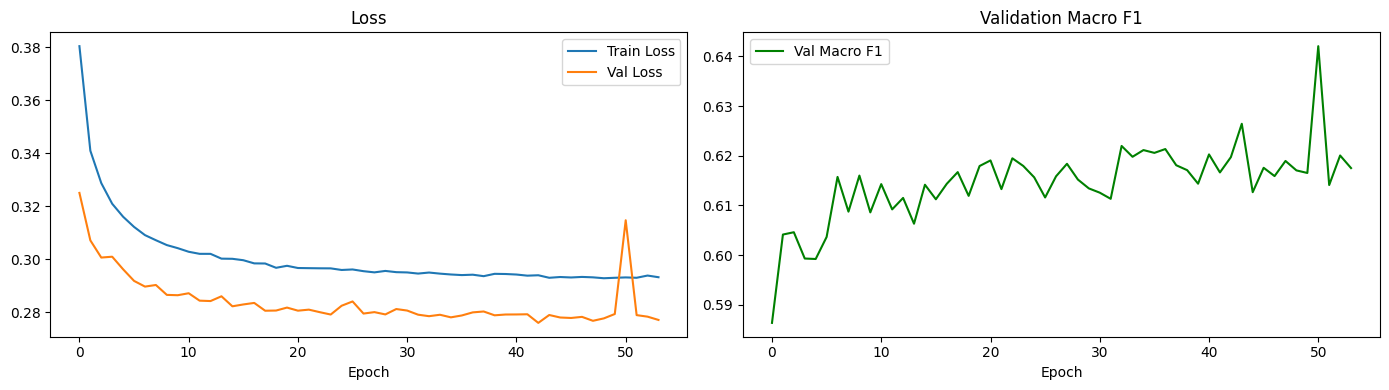

In [28]:
# ============================================================
# VALUTAZIONE SUL TEST SET
# ============================================================

model_nn.load_state_dict(torch.load('best_mlp_4.pt'))
model_nn.eval()

test_preds = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model_nn(X_batch)
        preds   = outputs.argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())

print("\n" + "="*60)
print("CLASSIFICATION REPORT - TEST SET")
print("="*60)
print(classification_report(y_test, test_preds,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['val_f1'], label='Val Macro F1', color='green')
axes[1].set_title('Validation Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## MODEL WITH FOCAL LOSS

In [33]:
# ============================================================
# PARAMETRI MLP - modifica qui
# ============================================================

# Architettura
HIDDEN_LAYERS = [512, 256, 128, 64]  # dimensione di ogni layer nascosto
DROPOUT_RATES = [0.3, 0.3, 0.2, 0.1]  # dropout per ogni layer

# Training
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4        # L2 regularization
BATCH_SIZE    = 4096
MAX_EPOCHS    = 150
PATIENCE      = 20

# Class weights - scale factor classe 0 (Severity 1)
SCALE_CLASS0  = 1.2
SCALE_CLASS3  = 1.1

# Scheduler
SCHEDULER_PATIENCE = 8
SCHEDULER_FACTOR   = 0.5

In [34]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.weight = weight
    
    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(
            weight=self.weight, reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

In [35]:
GAMMA = 2.0  # prova 1.0, 2.0, 3.0, 5.0

In [36]:
# ============================================================
# INIZIALIZZAZIONE
# ============================================================
input_dim = X_train.shape[1]
model_nn  = MLP(input_dim, HIDDEN_LAYERS, DROPOUT_RATES).to(device)

print(f"Architettura MLP:")
print(model_nn)
print(f"\nParametri totali: {sum(p.numel() for p in model_nn.parameters()):,}")
print(f"Input features:   {input_dim}")

# Pesi più leggeri rispetto a prima
class_counts = np.bincount(y_train)
weights = 1.0 / np.sqrt(class_counts)  # radice quadrata invece di inverso diretto
weights = weights / weights.sum() * 4
weights_tensor = torch.FloatTensor(weights).to(device)

criterion = FocalLoss(gamma=GAMMA, weight=weights_tensor)
optimizer  = torch.optim.Adam(model_nn.parameters(), 
                               lr=LEARNING_RATE, 
                               weight_decay=WEIGHT_DECAY)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='max',
                patience=SCHEDULER_PATIENCE,
                factor=SCHEDULER_FACTOR,
                verbose=True)

# DataLoader con batch size dai parametri
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), 
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),   
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), 
                          batch_size=BATCH_SIZE, shuffle=False)

Architettura MLP:
MLP(
  (network): Sequential(
    (0): Linear(in_features=74, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.1, inplace=False)
    (16): Linear(in_features=64, out_features=4, bias=True)
  )
)

Parametri totali: 213,060
Input features:   74


c:\Users\matti\University\ProgettoColloquio\Project_Security_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [37]:
# ============================================================
# TRAINING LOOP
# ============================================================
best_val_f1      = 0
patience_counter = 0
history          = {'train_loss': [], 'val_loss': [], 'val_f1': []}

print("\nInizio training...")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val Macro F1':>12} | {'LR':>8}")
print("-" * 60)

for epoch in range(MAX_EPOCHS):
    # Train
    model_nn.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs    = model_nn(X_batch)
        loss       = criterion(outputs, y_batch)        
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    model_nn.eval()
    val_preds, val_true = [], []
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs   = model_nn(X_batch)
            loss      = criterion(outputs, y_batch)
            val_loss += loss.item()
            preds     = outputs.argmax(dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(y_batch.cpu().numpy())
    
    val_f1    = f1_score(val_true, val_preds, average='macro')
    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    history['val_f1'].append(val_f1)
    
    scheduler.step(val_f1)
    
    print(f"{epoch+1:>6} | {avg_train:>10.4f} | {avg_val:>10.4f} | {val_f1:>12.4f} | {current_lr:>8.6f}")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_nn.state_dict(), 'best_mlp_Focal_1.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\nMiglior Val Macro F1: {best_val_f1:.4f}")


Inizio training...
 Epoch | Train Loss |   Val Loss | Val Macro F1 |       LR
------------------------------------------------------------
     1 |     0.0323 |     0.0202 |       0.5081 | 0.000100
     2 |     0.0217 |     0.0178 |       0.5288 | 0.000100
     3 |     0.0195 |     0.0165 |       0.5476 | 0.000100
     4 |     0.0182 |     0.0156 |       0.5586 | 0.000100
     5 |     0.0173 |     0.0151 |       0.5656 | 0.000100
     6 |     0.0166 |     0.0146 |       0.5702 | 0.000100
     7 |     0.0161 |     0.0143 |       0.5718 | 0.000100
     8 |     0.0157 |     0.0140 |       0.5843 | 0.000100
     9 |     0.0153 |     0.0137 |       0.5779 | 0.000100
    10 |     0.0150 |     0.0135 |       0.5821 | 0.000100
    11 |     0.0148 |     0.0134 |       0.5832 | 0.000100
    12 |     0.0146 |     0.0133 |       0.5848 | 0.000100
    13 |     0.0144 |     0.0132 |       0.5812 | 0.000100
    14 |     0.0143 |     0.0131 |       0.5884 | 0.000100
    15 |     0.0141 |     0.0130 |

KeyboardInterrupt: 


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

  Severity 1       0.11      0.94      0.19     13473
  Severity 2       0.99      0.77      0.87   1230289
  Severity 3       0.64      0.94      0.76    259850
  Severity 4       0.41      0.95      0.58     40702

    accuracy                           0.80   1544314
   macro avg       0.54      0.90      0.60   1544314
weighted avg       0.91      0.80      0.83   1544314



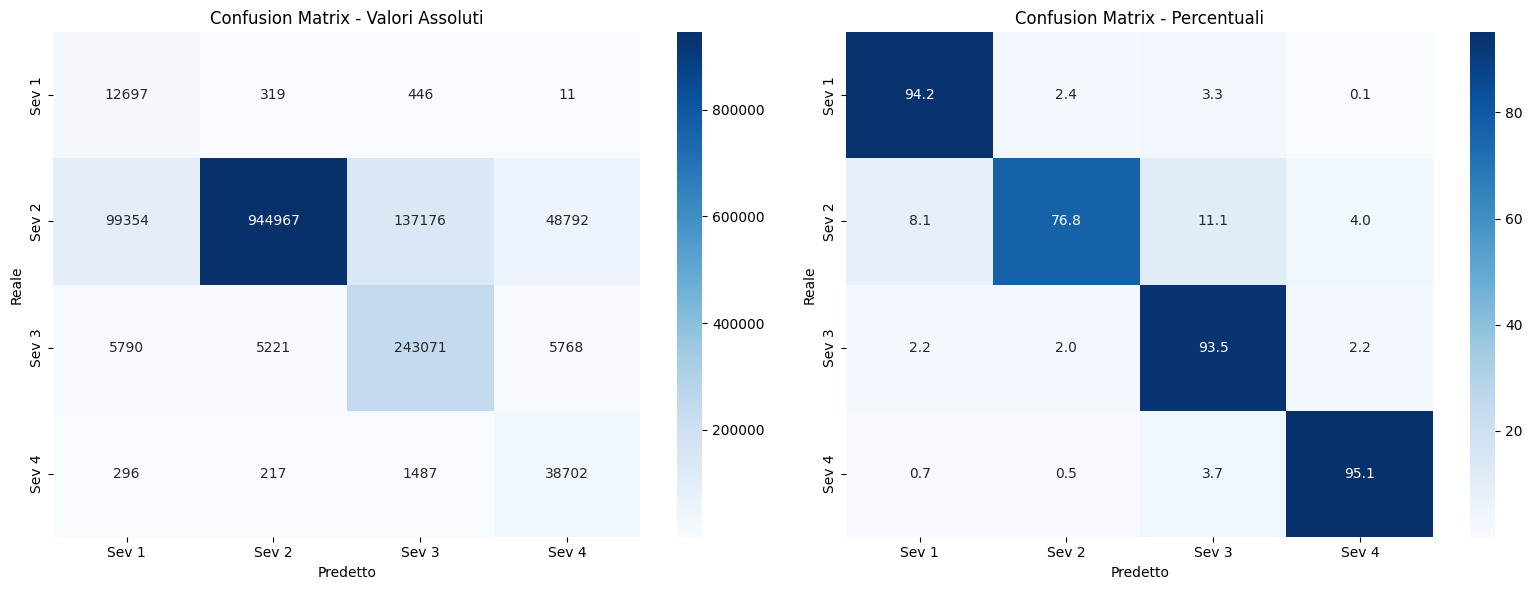

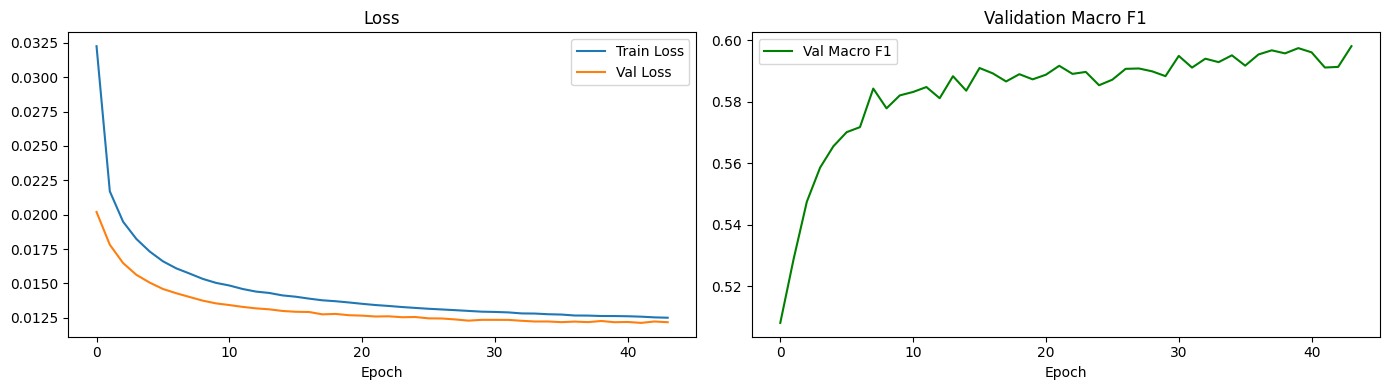

In [38]:
# ============================================================
# VALUTAZIONE SUL TEST SET
# ============================================================
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model_nn.load_state_dict(torch.load('best_mlp_Focal_1.pt'))
model_nn.eval()

test_preds = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model_nn(X_batch)
        preds   = outputs.argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())

print("\n" + "="*60)
print("CLASSIFICATION REPORT - TEST SET")
print("="*60)
print(classification_report(y_test, test_preds,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentuali')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['val_f1'], label='Val Macro F1', color='green')
axes[1].set_title('Validation Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## RESIDUAL MLP

In [23]:
# ============================================================
# PARAMETRI RESIDUAL MLP - modifica qui
# ============================================================

# Architettura
HIDDEN_DIM    = 512    # dimensione dei residual block
NUM_BLOCKS    = 5      # numero di residual block
DROPOUT_RATES = [0.3, 0.3, 0.2, 0.2, 0.1]  # uno per block

# Training
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-4
BATCH_SIZE    = 2048
MAX_EPOCHS    = 150
PATIENCE      = 20
SCALE_CLASS0  = 1.2
SCALE_CLASS3  = 1.1

# Focal Loss
GAMMA = 1.0

# Scheduler
SCHEDULER_PATIENCE = 8
SCHEDULER_FACTOR   = 0.5

In [24]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()
    
    def forward(self, x):
        return self.relu(x + self.block(x))  # skip connection

class ResidualMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_blocks, dropout_rates):
        super().__init__()
        
        # Proiezione input → hidden_dim
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rates[0])
        )
        
        # Residual blocks
        self.res_blocks = nn.Sequential(*[
            ResidualBlock(hidden_dim, dropout_rates[i])
            for i in range(num_blocks)
        ])
        
        # Output
        self.output = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rates[-1]),
            nn.Linear(hidden_dim // 2, 4)
        )
    
    def forward(self, x):
        x = self.input_proj(x)
        x = self.res_blocks(x)
        return self.output(x)

In [25]:
input_dim = X_train.shape[1]
model_nn  = ResidualMLP(input_dim, HIDDEN_DIM, NUM_BLOCKS, DROPOUT_RATES).to(device)

print(f"Architettura Residual MLP:")
print(model_nn)
print(f"\nParametri totali: {sum(p.numel() for p in model_nn.parameters()):,}")
print(f"Input features:   {input_dim}")

class_counts    = np.bincount(y_train)
weights         = 1.0 / class_counts
weights[0]     *= SCALE_CLASS0
weights[3]     *= SCALE_CLASS3
weights         = weights / weights.sum()
weights         = weights * 4
weights_tensor  = torch.FloatTensor(weights).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(model_nn.parameters(),
                              lr=LEARNING_RATE,
                              weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min',    
                patience=SCHEDULER_PATIENCE,
                factor=SCHEDULER_FACTOR,
                verbose=True)

# DataLoader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False)

Architettura Residual MLP:
ResidualMLP(
  (input_proj): Sequential(
    (0): Linear(in_features=74, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=512, out_features=512, bias=True)
        (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.3, inplace=False)
        (4): Linear(in_features=512, out_features=512, bias=True)
        (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=512, out_features=512, bias=True)
        (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): R

c:\Users\matti\University\ProgettoColloquio\Project_Security_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [42]:
best_val_f1   = 0
best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

print("\nInizio training...")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val Macro F1':>12} | {'LR':>8}")
print("-" * 60)

for epoch in range(MAX_EPOCHS):
    # Train
    model_nn.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs    = model_nn(X_batch)
        loss       = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    model_nn.eval()
    val_preds, val_true = [], []
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs   = model_nn(X_batch)
            loss      = criterion(outputs, y_batch)
            val_loss += loss.item()
            preds     = outputs.argmax(dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(y_batch.cpu().numpy())
    
    val_f1     = f1_score(val_true, val_preds, average='macro')
    avg_train  = train_loss / len(train_loader)
    avg_val    = val_loss   / len(val_loader)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    history['val_f1'].append(val_f1)
    
    # Scheduler basato su val loss (più stabile)
    scheduler.step(avg_val)
    
    print(f"{epoch+1:>6} | {avg_train:>10.4f} | {avg_val:>10.4f} | {val_f1:>12.4f} | {current_lr:>8.6f}")
    
    # Salva il modello con F1 migliore
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_nn.state_dict(), 'best_residual_mlp.pt')
        print(f"         → Salvato nuovo miglior F1: {best_val_f1:.4f}")
    
    # Early stopping basato su val loss
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            print(f"Miglior Val Loss: {best_val_loss:.4f}")
            print(f"Miglior Val F1:   {best_val_f1:.4f}")
            break

print(f"\nMiglior Val Macro F1: {best_val_f1:.4f}")
print(f"Miglior Val Loss:     {best_val_loss:.4f}")


Inizio training...
 Epoch | Train Loss |   Val Loss | Val Macro F1 |       LR
------------------------------------------------------------
     1 |     0.4124 |     0.3283 |       0.5851 | 0.000300
         → Salvato nuovo miglior F1: 0.5851
     2 |     0.3393 |     0.3071 |       0.6013 | 0.000300
         → Salvato nuovo miglior F1: 0.6013
     3 |     0.3198 |     0.2984 |       0.5923 | 0.000300
     4 |     0.3100 |     0.2906 |       0.6047 | 0.000300
         → Salvato nuovo miglior F1: 0.6047
     5 |     0.3017 |     0.2865 |       0.6073 | 0.000300
         → Salvato nuovo miglior F1: 0.6073
     6 |     0.2971 |     0.2832 |       0.5981 | 0.000300
     7 |     0.2920 |     0.2814 |       0.6109 | 0.000300
         → Salvato nuovo miglior F1: 0.6109
     8 |     0.2890 |     0.2778 |       0.6100 | 0.000300
     9 |     0.2848 |     0.2766 |       0.6076 | 0.000300
    10 |     0.2833 |     0.2727 |       0.6187 | 0.000300
         → Salvato nuovo miglior F1: 0.6187
    11


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

  Severity 1       0.16      0.92      0.27     13473
  Severity 2       0.99      0.83      0.90   1230289
  Severity 3       0.69      0.93      0.79    259850
  Severity 4       0.45      0.94      0.61     40702

    accuracy                           0.85   1544314
   macro avg       0.57      0.91      0.64   1544314
weighted avg       0.92      0.85      0.87   1544314



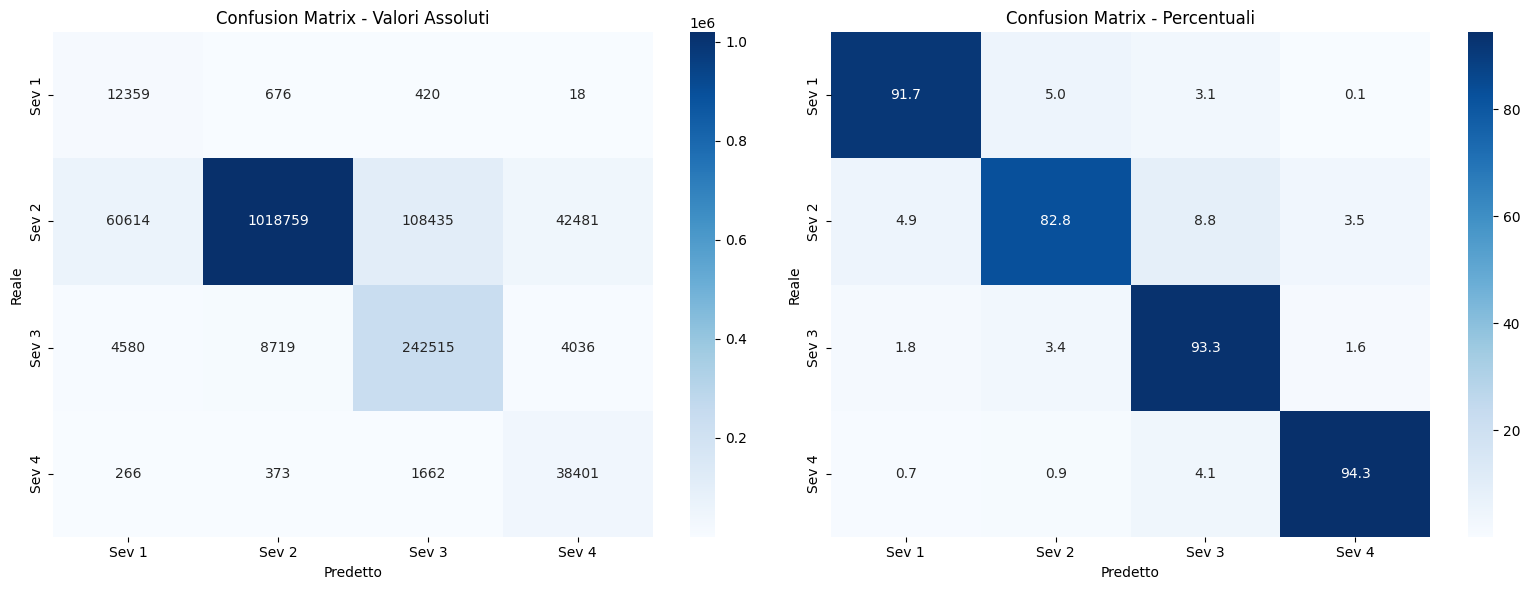

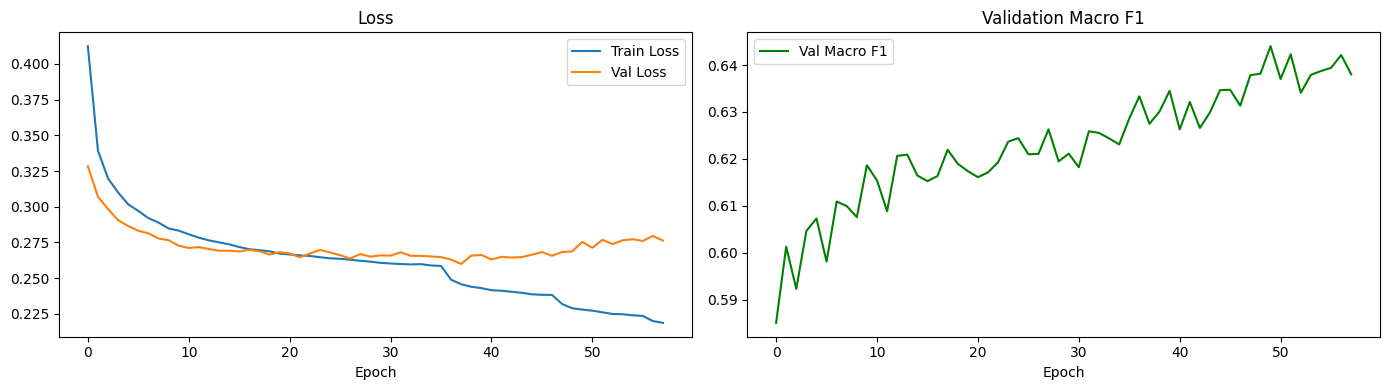

In [44]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model_nn.load_state_dict(torch.load('best_residual_mlp.pt'))
model_nn.eval()

test_preds = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model_nn(X_batch)
        preds   = outputs.argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())

print("\n" + "="*60)
print("CLASSIFICATION REPORT - TEST SET")
print("="*60)
print(classification_report(y_test, test_preds,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentuali')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['val_f1'], label='Val Macro F1', color='green')
axes[1].set_title('Validation Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
import torch
import numpy as np
import joblib as jbl
from torch.utils.data import DataLoader, TensorDataset

# ============================================================
# RICOSTRUISCI IL MODELLO E CARICA I PESI
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

input_dim = X_train.shape[1]
model_nn  = ResidualMLP(input_dim, HIDDEN_DIM, NUM_BLOCKS, DROPOUT_RATES).to(device)
model_nn.load_state_dict(torch.load('best_residual_mlp.pt', map_location=device))
model_nn.eval()
print(f"Modello caricato! Input dim: {input_dim}")

# ============================================================
# FUNZIONE PER ESTRARRE PROBABILITÀ
# ============================================================
def get_probs(loader, model, device):
    probs_list = []
    with torch.no_grad():
        for (batch,) in loader:
            batch   = batch.to(device)
            outputs = model(batch)
            probs   = torch.softmax(outputs, dim=1)
            probs_list.append(probs.cpu().numpy())
    return np.concatenate(probs_list)

# ============================================================
# DATALOADER SENZA LABEL (solo X)
# ============================================================
val_loader_x  = DataLoader(TensorDataset(X_val_t),
                            batch_size=4096, shuffle=False)
test_loader_x = DataLoader(TensorDataset(X_test_t),
                            batch_size=4096, shuffle=False)

# ============================================================
# CALCOLA E SALVA PROBABILITÀ
# ============================================================
print("Calcolo probabilità su val set...")
nn_val_probs = get_probs(val_loader_x, model_nn, device)
jbl.dump(nn_val_probs, 'nn_val_probs.pkl')
print(f"Val probs salvate! Shape: {nn_val_probs.shape}")

print("Calcolo probabilità su test set...")
nn_test_probs = get_probs(test_loader_x, model_nn, device)
jbl.dump(nn_test_probs, 'nn_test_probs.pkl')
print(f"Test probs salvate! Shape: {nn_test_probs.shape}")

# Salva anche lo scaler per usi futuri
jbl.dump(scaler, 'nn_scaler.pkl')
print("Scaler salvato!")

Usando: cuda
Modello caricato! Input dim: 74
Calcolo probabilità su val set...
Val probs salvate! Shape: (1235451, 4)
Calcolo probabilità su test set...
Test probs salvate! Shape: (1544314, 4)
Scaler salvato!
